# Model 4: Extreme Gradient Boosting

We have reached the final stage of our modeling pipeline. 
In Phase 2, the **Decision Tree** had high variance (rigid staircases). 
In Phase 3 , the **Random Forest** smoothed out the variance using Bagging, but suffered from slight overfitting and struggled to overcome hard-coded feature engineering.

Now, we introduce **XGBoost (Extreme Gradient Boosting)**. 
Instead of building deep trees independently, XGBoost builds very shallow trees sequentially. Each tree explicitly focuses on correcting the errors (residuals) of the previous tree. This minimizes *bias* and naturally resists overfitting, making it the ultimate algorithm for tabular data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv('../data/final/ml_ready_dataset.csv')
X = df.select_dtypes(exclude=['object', 'string']).drop(columns=['is_returned'], errors='ignore')
y = df['is_returned']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


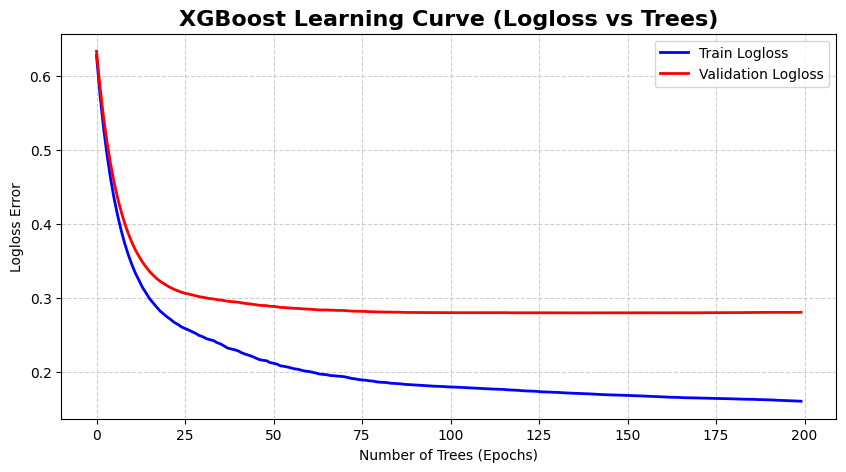

In [3]:

eval_set = [(X_train_resampled, y_train_resampled), (X_val, y_val)]
xgb_baseline = xgb.XGBClassifier(
    n_estimators=200, 
    learning_rate=0.1, 
    random_state=42, 
    eval_metric="logloss"
)
xgb_baseline.fit(X_train_resampled, y_train_resampled, eval_set=eval_set, verbose=False)

#  Plot Learning Curve
results = xgb_baseline.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train Logloss', color="blue", linewidth=2)
plt.plot(x_axis, results['validation_1']['logloss'], label='Validation Logloss', color="red", linewidth=2)
plt.legend()
plt.title('XGBoost Learning Curve (Logloss vs Trees)', fontsize=16, fontweight="bold")
plt.xlabel('Number of Trees (Epochs)')
plt.ylabel('Logloss Error')
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


> As the number of trees increases, the training error continuously drops, but the validation error eventually flattens out (around 50-100 trees). This is the exact moment XGBoost realizes further training will lead to overfitting. We can use this knowledge to tune our hyperparameters.

### Hyperparameter Tuning for Bias Reduction
To maximize our ROC-AUC, run a GridSearch. 
- `max_depth`: Keep trees shallow (3 to 6) to prevent memorization.
- `learning_rate`: A smaller rate (0.05) forces the model to learn slowly and robustly.
- `subsample`: Randomly drop a percentage of data per tree to introduce healthy noise.

In [ ]:
# Instead of guessing n_estimators, we use Early Stopping!
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Initialize XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=1000, random_state=42, eval_metric="logloss")

grid_search = GridSearchCV(
    xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_resampled, y_train_resampled)
print(f"Best Hyperparameters (excluding n_trees): {grid_search.best_params_}")

#  Early Stopping!
best_xgb = xgb.XGBClassifier(
    **grid_search.best_params_,
    n_estimators=2000,
    early_stopping_rounds=50, ## 50 consecutive value give logloss decreasing
    random_state=42,
    eval_metric="logloss"
)

best_xgb.fit(X_train_resampled, y_train_resampled, eval_set=[(X_test, y_test)], verbose=100)
print(f"\nOptimal number of trees found by Early Stopping: {best_xgb.best_iteration}")


Best Hyperparameters (excluding n_trees): {'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}
[0]	validation_0-logloss:0.66232
[100]	validation_0-logloss:0.27973
[200]	validation_0-logloss:0.27210
[294]	validation_0-logloss:0.27194

Optimal number of trees found by Early Stopping: 244


C:\Users\ASUS\AppData\Local\Temp\ipykernel_10504\3224498576.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_configs, x='mean_test_score', y=[str(p) for p in top_configs['params']], palette="viridis")


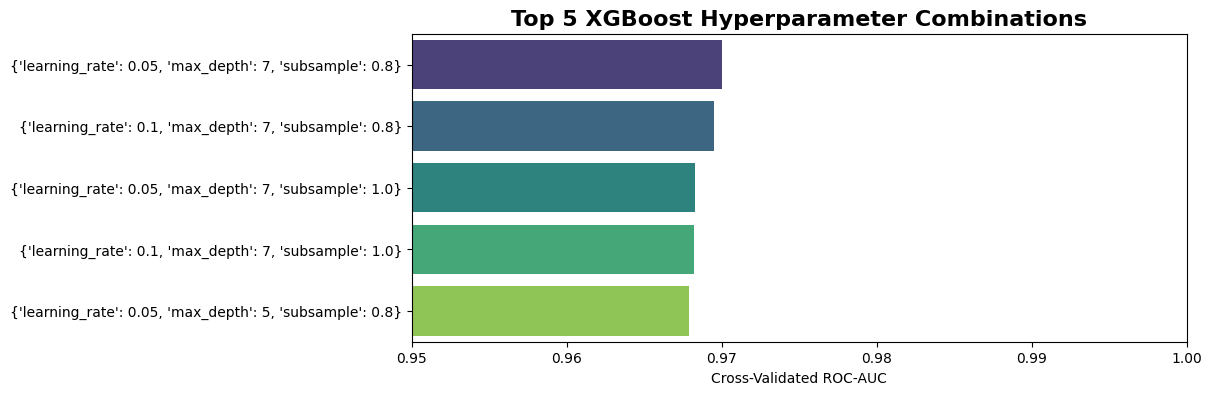

Best Hyperparameters Discovered: {'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}


In [ ]:

# Create a bar chart of the top 5 configs
results_df = pd.DataFrame(grid_search.cv_results_)
top_configs = results_df.sort_values(by='rank_test_score').head(5)

plt.figure(figsize=(10, 4))
sns.barplot(data=top_configs, x='mean_test_score', y=[str(p) for p in top_configs['params']], palette="viridis")
plt.title('Top 5 XGBoost Hyperparameter Combinations', fontsize=16, fontweight="bold")
plt.xlabel('Cross-Validated ROC-AUC')
plt.xlim(0.95, 1.0) # Zoom in on the high scores
plt.show()


> **Step 2 Conclusion:** By strictly limiting `max_depth` and using `subsample`, we prevent the deep-tree overfitting we saw in Random Forest. The winning configuration balances a slow learning rate with enough trees to accurately capture the signal.

### Step 3: Final Model Evaluation
Using our optimized XGBoost model, we predict on the holdout `X_test` dataset. We will plot a Confusion Matrix and the all-important ROC Curve to see if we cracked the 0.90 barrier.

Optimized XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     15900
           1       0.84      0.62      0.72      3500

    accuracy                           0.91     19400
   macro avg       0.88      0.80      0.83     19400
weighted avg       0.91      0.91      0.91     19400

Final ROC-AUC Score: 0.8775



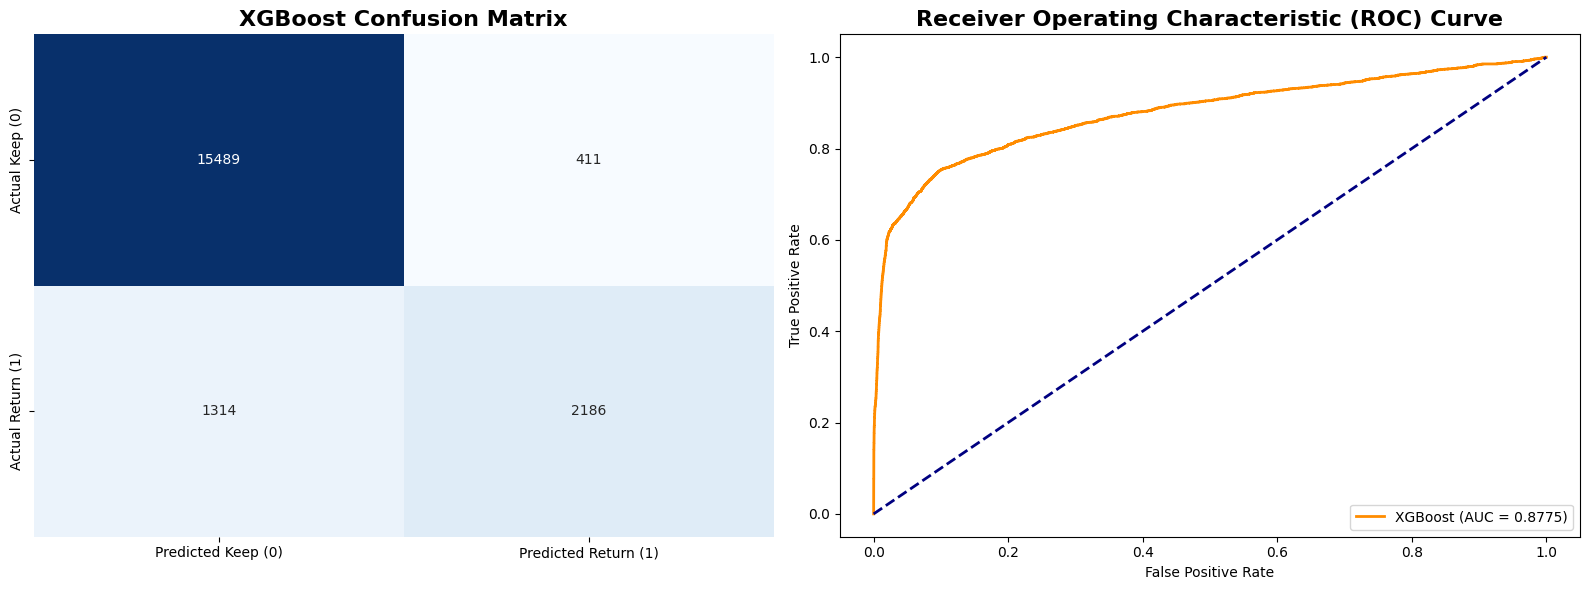

In [11]:
preds = best_xgb.predict(X_test)
probs = best_xgb.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, probs)

print("Optimized XGBoost Classification Report:")
print(classification_report(y_test, preds))
print(f"Final ROC-AUC Score: {final_auc:.4f}\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Keep (0)', 'Predicted Return (1)'],
            yticklabels=['Actual Keep (0)', 'Actual Return (1)'], ax=axes[0])
axes[0].set_title('XGBoost Confusion Matrix', fontsize=16, fontweight='bold')

# Plot 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {final_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


### Step 4: The 3 Faces of Feature Importance
XGBoost is unique because it calculates feature importance in three different ways:
1. **Weight**: The number of times a feature is used to split the data across all trees.
2. **Gain**: The average improvement in accuracy brought by a feature.
3. **Cover**: The relative quantity of observations concerned by a feature.

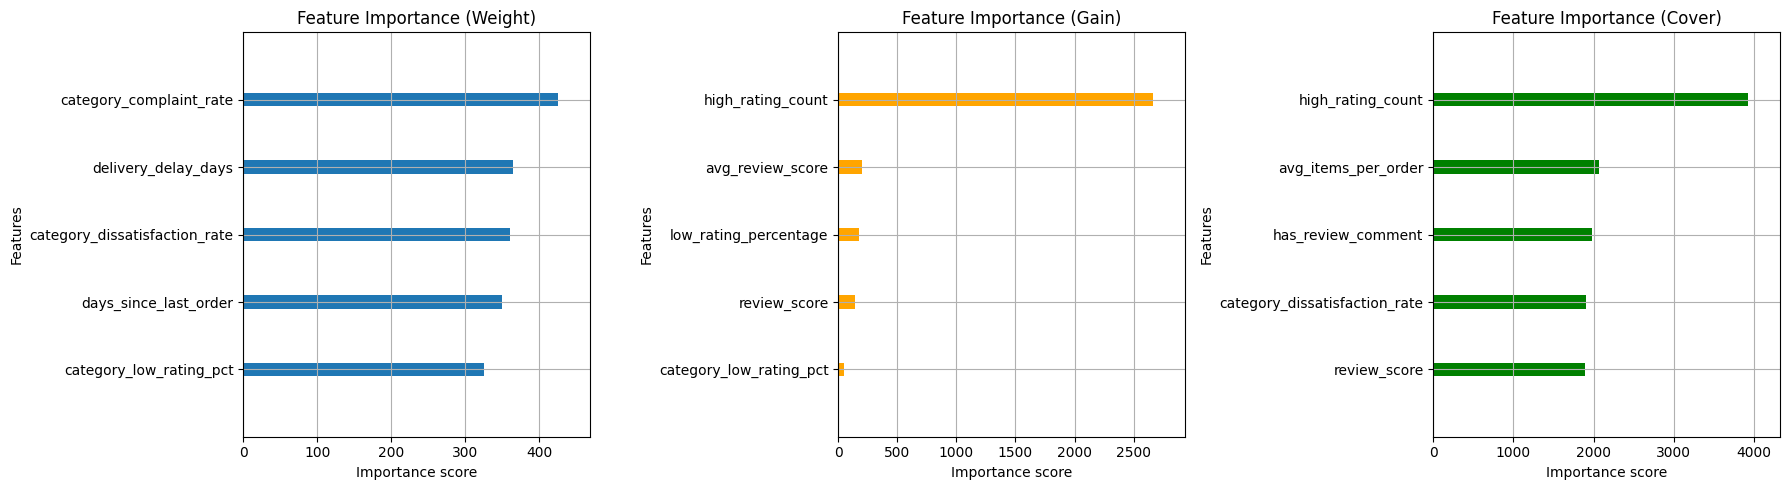

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
xgb.plot_importance(best_xgb, importance_type='weight', max_num_features=5, ax=axes[0], title='Feature Importance (Weight)', show_values=False)
xgb.plot_importance(best_xgb, importance_type='gain', max_num_features=5, ax=axes[1], title='Feature Importance (Gain)', show_values=False, color="orange")
xgb.plot_importance(best_xgb, importance_type='cover', max_num_features=5, ax=axes[2], title='Feature Importance (Cover)', show_values=False, color="green")
plt.tight_layout()
plt.show()
